In [1]:
import sys
print(sys.executable)

/Users/youshaabdullah/VSCode_Projects/Ionosphere_GNSS/GNSS/bin/python


# STEP 1 — LOAD AND PREPROCESS

In [54]:
import pandas as pd
import numpy as np

file_path = '/Users/youshaabdullah/VSCode_Projects/Ionosphere_GNSS/Data_Preprocessed/2019-15--120-152181_preprocessed.csv'
df = pd.read_csv(file_path)

# ================================
# TIME FEATURES
# ================================
df['Time_index'] = range(len(df))
df['Day'] = df.index // 24
df['Time_sec'] = df.index * 3600
df['Time_Min'] = df.index * 60

df['sin_time'] = np.sin(2 * np.pi * df['Time/h'] / 24)
df['cos_time'] = np.cos(2 * np.pi * df['Time/h'] / 24)

# ================================
# ROT
# ================================
df['ROT'] = df['VTEC'].diff() / df['Time_sec'].diff()
df['ROT_per_min'] = df['ROT'] * 60

# ================================
# ROTI (6 hour rolling std)
# ================================
df['ROTI_6hr'] = df['ROT_per_min'].rolling(window=6).std()

# STEP 2 — CREATE TARGET CLASS

In [56]:
roti_values = df['ROTI_6hr']

conditions = [
    roti_values < 0.01,
    (roti_values >= 0.01) & (roti_values < 0.03),
    (roti_values >= 0.03) & (roti_values < 0.07),
    roti_values >= 0.07
]

labels = np.array([
    "Quiet",
    "Weak",
    "Moderate",
    "Strong"
], dtype=object)

df['ionosphere_name'] = np.select(conditions, labels, default="Unknown")

# STEP 3 — NUMERICAL TARGET LABEL

In [57]:
mapping = {
    'Quiet': 0,
    'Weak': 1,
    'Moderate': 2,
    'Strong': 3
}

df['target'] = df['ionosphere_name'].map(mapping)

# STEP 4 — REMOVE NaN ROWS CAUSED BY DIFF + ROLLING


In [58]:
df = df.dropna()
df

,Time/h,Lat,Lon,VTEC,Time_index,Day,Time_sec,Time_Min,sin_time,cos_time,ROT,ROT_per_min,ROTI_6hr,ionosphere_name,target
6,6,15,-120,59,6,0,21600,360,1.000000,6.123234e-17,-0.003333,-0.200000,0.495947,Strong,3.0
7,7,15,-120,56,7,0,25200,420,0.965926,-2.588190e-01,-0.000833,-0.050000,0.492772,Strong,3.0
8,8,15,-120,51,8,0,28800,480,0.866025,-5.000000e-01,-0.001389,-0.083333,0.503258,Strong,3.0
9,9,15,-120,53,9,0,32400,540,0.707107,-7.071068e-01,0.000556,0.033333,0.500157,Strong,3.0
10,10,15,-120,48,10,0,36000,600,0.500000,-8.660254e-01,-0.001389,-0.083333,0.182168,Strong,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
715,19,15,-120,136,715,29,2574000,42900,-0.965926,2.588190e-01,0.003056,0.183333,0.138911,Strong,3.0
716,20,15,-120,146,716,29,2577600,42960,-0.866025,5.000000e-01,0.002778,0.166667,0.134061,Strong,3.0
717,21,15,-120,158,717,29,2581200,43020,-0.707107,7.071068e-01,0.003333,0.200000,0.045542,Moderate,2.0
718,22,15,-120,166,718,29,2584800,43080,-0.500000,8.660254e-01,0.002222,0.133333,0.041388,Moderate,2.0


# STEP 5 — VIEW CLASS DISTRIBUTION

In [60]:
# df[df.target == 0]   # Quiet
# df[df.target == 1]   # Weak
# df[df.target == 2]   # Moderate
df[df.target == 3]   # Strong

,Time/h,Lat,Lon,VTEC,Time_index,Day,Time_sec,Time_Min,sin_time,cos_time,ROT,ROT_per_min,ROTI_6hr,ionosphere_name,target
6,6,15,-120,59,6,0,21600,360,1.000000,6.123234e-17,-0.003333,-0.200000,0.495947,Strong,3.0
7,7,15,-120,56,7,0,25200,420,0.965926,-2.588190e-01,-0.000833,-0.050000,0.492772,Strong,3.0
8,8,15,-120,51,8,0,28800,480,0.866025,-5.000000e-01,-0.001389,-0.083333,0.503258,Strong,3.0
9,9,15,-120,53,9,0,32400,540,0.707107,-7.071068e-01,0.000556,0.033333,0.500157,Strong,3.0
10,10,15,-120,48,10,0,36000,600,0.500000,-8.660254e-01,-0.001389,-0.083333,0.182168,Strong,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
713,17,15,-120,110,713,29,2566800,42780,-0.965926,-2.588190e-01,0.002500,0.150000,0.211454,Strong,3.0
714,18,15,-120,125,714,29,2570400,42840,-1.000000,-1.836970e-16,0.004167,0.250000,0.187380,Strong,3.0
715,19,15,-120,136,715,29,2574000,42900,-0.965926,2.588190e-01,0.003056,0.183333,0.138911,Strong,3.0
716,20,15,-120,146,716,29,2577600,42960,-0.866025,5.000000e-01,0.002778,0.166667,0.134061,Strong,3.0


# STEP 6 — VISUALIZE DIFFERENT IONOSPHERE GROUPS

In [61]:
df0 = df[df.target == 0]
df1 = df[df.target == 1]
df2 = df[df.target == 2]
df3 = df[df.target == 3]

# 6.Plot 1 — VTEC vs ROT

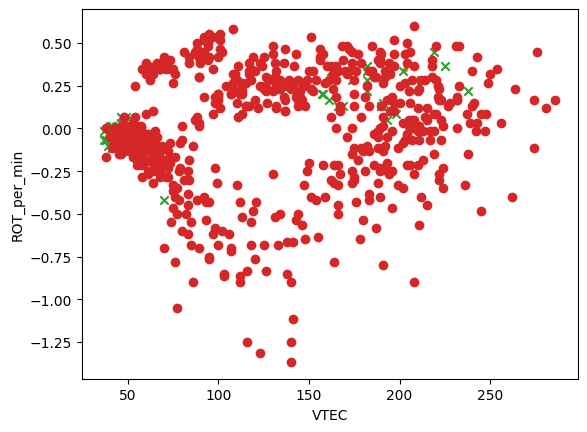

In [62]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.xlabel('VTEC')
plt.ylabel('ROT_per_min')

plt.scatter(df0['VTEC'], df0['ROT_per_min'], marker='+')
plt.scatter(df1['VTEC'], df1['ROT_per_min'], marker='.')
plt.scatter(df2['VTEC'], df2['ROT_per_min'], marker='x')
plt.scatter(df3['VTEC'], df3['ROT_per_min'], marker='o')
plt.show()

# 6.Plot 2 — ROT vs ROTI

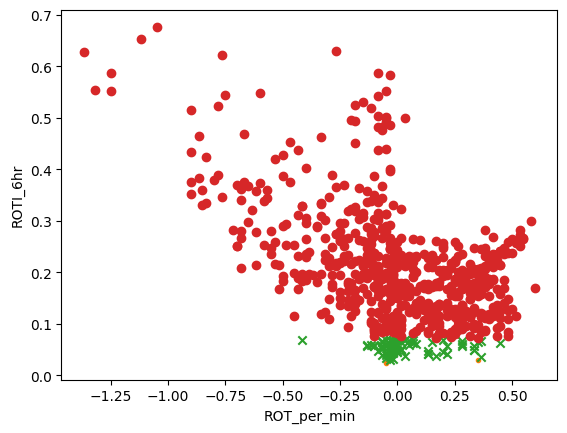

In [63]:
plt.xlabel('ROT_per_min')
plt.ylabel('ROTI_6hr')

plt.scatter(df0['ROT_per_min'], df0['ROTI_6hr'], marker='+')
plt.scatter(df1['ROT_per_min'], df1['ROTI_6hr'], marker='.')
plt.scatter(df2['ROT_per_min'], df2['ROTI_6hr'], marker='x')
plt.scatter(df3['ROT_per_min'], df3['ROTI_6hr'], marker='o')
plt.show()

# STEP 7 — TRAIN USING SVM

In [64]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

# STEP 8 — TRAIN SVM MODEL

In [65]:
X = df[['VTEC','ROT_per_min','ROTI_6hr','sin_time','cos_time','Time_index','Day']]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# STEP 9 — CHECK ACCURACY

In [66]:
model = SVC()
model.fit(X_train, y_train)
model.score(X_test, y_test)

0.8951048951048951

# STEP 10 — PREDICT

In [67]:
model.predict(X_test[:5])

array([3., 3., 3., 3., 3.])

# STEP 11 — HYPERPARAMETER TUNING

## (a) Regularization C

In [ ]:
model_C = SVC(C=10)
model_C.fit(X_train, y_train)
model_C.score(X_test, y_test)

## (b) Gamma

In [ ]:
model_g = SVC(gamma=1)
model_g.fit(X_train, y_train)
model_g.score(X_test, y_test)

## (c) Kernel


In [ ]:
model_linear = SVC(kernel='linear')
model_linear.fit(X_train, y_train)
model_linear.score(X_test, y_test)